In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
import pandas as pd
import numpy as np
np.random.seed(42)

n = 1500
airlines = ['IndiGo', 'Air India', 'SpiceJet', 'Vistara', 'GoAir']
sources = ['Delhi', 'Mumbai', 'Bangalore', 'Chennai', 'Hyderabad']
destinations = ['Kolkata', 'Delhi', 'Mumbai', 'Bangalore', 'Chennai']
stops = ['non-stop', '1 stop', '2 stops']
classes = ['Economy', 'Business']

df = pd.DataFrame({
    'Airline': np.random.choice(airlines, n),
    'Source': np.random.choice(sources, n),
    'Destination': np.random.choice(destinations, n),
    'Duration_Hours': np.random.randint(1, 12, n),
    'Total_Stops': np.random.choice(stops, n),
    'Class': np.random.choice(classes, n),
    'Days_Left': np.random.randint(1, 60, n),
    'Price': np.random.randint(2500, 25000, n)
})

df.to_csv("Flight_Price_1500.csv", index=False)

print("Flight_Price_1500.csv created successfully!")
print(df.head())

Flight_Price_1500.csv created successfully!
    Airline     Source Destination  Duration_Hours Total_Stops     Class  \
0   Vistara    Chennai      Mumbai              10    non-stop   Economy   
1     GoAir     Mumbai     Chennai               7    non-stop   Economy   
2  SpiceJet    Chennai     Kolkata               7    non-stop   Economy   
3     GoAir  Bangalore     Chennai               1      1 stop   Economy   
4     GoAir      Delhi       Delhi               9      1 stop  Business   

   Days_Left  Price  
0         38  23890  
1         56  15813  
2         54   4059  
3         57  20625  
4          5  17667  


In [3]:
df = pd.read_csv("Flight_Price_1500.csv")
df.head()

,Airline,Source,Destination,Duration_Hours,Total_Stops,Class,Days_Left,Price
0,Vistara,Chennai,Mumbai,10,non-stop,Economy,38,23890
1,GoAir,Mumbai,Chennai,7,non-stop,Economy,56,15813
2,SpiceJet,Chennai,Kolkata,7,non-stop,Economy,54,4059
3,GoAir,Bangalore,Chennai,1,1 stop,Economy,57,20625
4,GoAir,Delhi,Delhi,9,1 stop,Business,5,17667


In [4]:
df.tail()

,Airline,Source,Destination,Duration_Hours,Total_Stops,Class,Days_Left,Price
1495,Vistara,Chennai,Kolkata,9,1 stop,Business,54,21864
1496,GoAir,Hyderabad,Delhi,2,non-stop,Economy,55,24376
1497,GoAir,Bangalore,Mumbai,8,2 stops,Business,14,12051
1498,Vistara,Mumbai,Bangalore,8,non-stop,Economy,58,23643
1499,Vistara,Chennai,Kolkata,4,non-stop,Business,25,16679


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Airline         1500 non-null   object
 1   Source          1500 non-null   object
 2   Destination     1500 non-null   object
 3   Duration_Hours  1500 non-null   int64 
 4   Total_Stops     1500 non-null   object
 5   Class           1500 non-null   object
 6   Days_Left       1500 non-null   int64 
 7   Price           1500 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 93.9+ KB


In [6]:
df.describe()

,Duration_Hours,Days_Left,Price
count,1500.000000,1500.000000,1500.000000
mean,6.109333,29.077333,13731.926000
std,3.126643,16.969757,6564.886479
min,1.000000,1.000000,2511.000000
25%,3.000000,14.000000,7865.500000
50%,6.000000,28.000000,13776.000000
75%,9.000000,43.000000,19609.750000
max,11.000000,59.000000,24996.000000


In [7]:
df.isnull().sum()

Airline           0
Source            0
Destination       0
Duration_Hours    0
Total_Stops       0
Class             0
Days_Left         0
Price             0
dtype: int64

In [8]:
print(df.columns)

Index(['Airline', 'Source', 'Destination', 'Duration_Hours', 'Total_Stops',
       'Class', 'Days_Left', 'Price'],
      dtype='object')


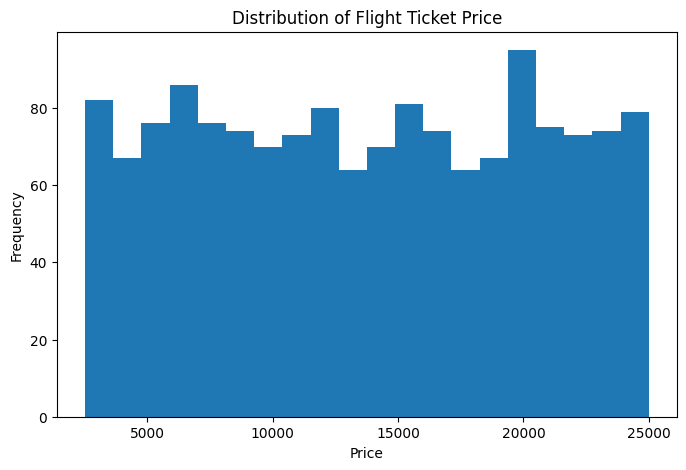

In [9]:
import matplotlib.pylab as plt
plt.figure(figsize=(8,5))
plt.hist(df['Price'], bins=20)
plt.title("Distribution of Flight Ticket Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


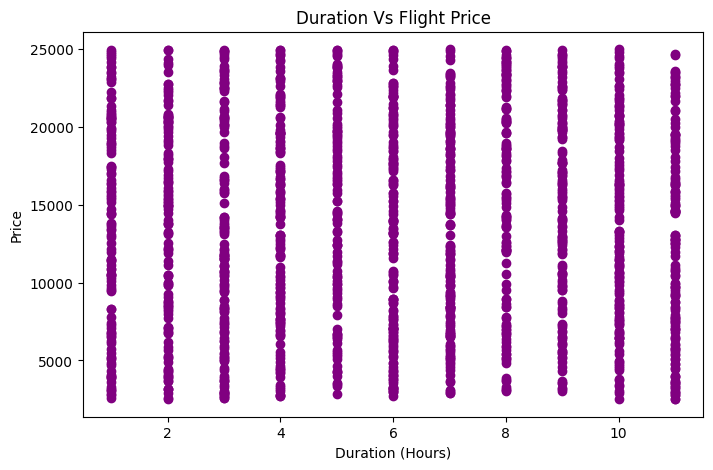

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df['Duration_Hours'],df['Price'], color='purple')
plt.title("Duration Vs Flight Price")
plt.xlabel("Duration (Hours)")
plt.ylabel("Price")
plt.show()

<Figure size 800x500 with 0 Axes>

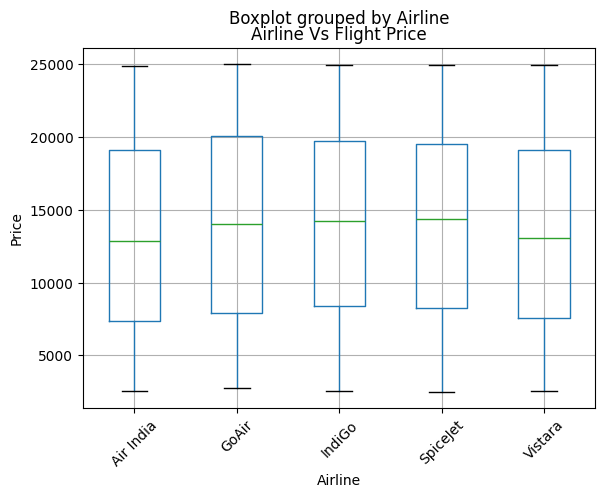

In [11]:
plt.figure(figsize=(8,5))
df.boxplot(column='Price',by='Airline')
plt.title("Airline Vs Flight Price")
plt.xlabel("Airline")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

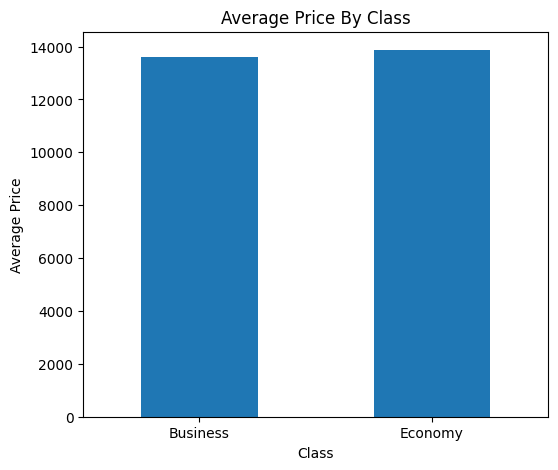

In [12]:
avg_Price = df.groupby('Class')['Price'].mean()
plt.figure(figsize=(6,5))
avg_Price.plot(kind='bar')
plt.title("Average Price By Class")
plt.xlabel("Class")
plt.ylabel("Average Price")
plt.xticks(rotation=0)
plt.show()

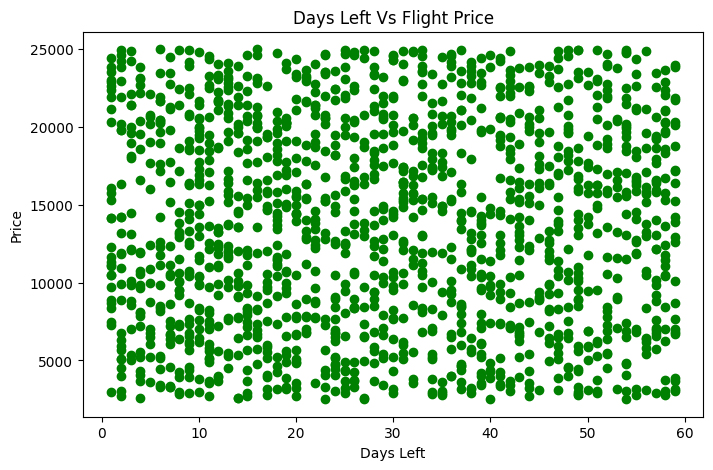

In [13]:
plt.figure(figsize=(8,5))
plt.scatter(df['Days_Left'], df['Price'],color='green')
plt.title("Days Left Vs Flight Price")
plt.xlabel("Days Left")
plt.ylabel("Price")
plt.show()

In [24]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Airline"]=le.fit_transform(df["Airline"])
df["Source"]=le.fit_transform(df["Source"])
df["Destination"]=le.fit_transform(df["Destination"])
df['Total_Stops'] = le.fit_transform(df['Total_Stops'])
df["Class"]=le.fit_transform(df["Class"])
print(df.head())

   Airline  Source  Destination  Duration_Hours  Total_Stops  Class  \
0        4       1            4              10            2      1   
1        1       4            1               7            2      1   
2        3       1            3               7            2      1   
3        1       0            1               1            0      1   
4        1       2            2               9            0      0   

   Days_Left  Price  
0         38  23890  
1         56  15813  
2         54   4059  
3         57  20625  
4          5  17667  


In [15]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train)
print(X_test)
print(y_train)
print(y_test)


      Airline  Source  Destination  Duration_Hours  Total_Stops  Class  \
382         2       3            0               3            2      1   
538         0       1            2              11            2      1   
1493        0       2            3               8            1      0   
1112        0       4            3               1            0      0   
324         2       2            4               9            1      0   
...       ...     ...          ...             ...          ...    ...   
1130        0       4            1              11            2      1   
1294        3       0            1               2            2      0   
860         2       4            2               4            1      1   
1459        1       2            0               6            2      0   
1126        4       2            1              11            0      0   

      Days_Left  
382          11  
538          42  
1493         57  
1112         33  
324          43  
...

In [17]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[13500.89313145 13967.20595172 13627.3568114  13548.42740844
 13233.38223389 13916.49429907 13097.47192586 13460.35987302
 13751.38432538 13431.21928522]


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 5632.1704868975285
Mean Squared Error (MSE): 42408998.6993588
Root Mean Squared Error (RMSE): 6512.219183915633
R² Score: -0.014394661449429469


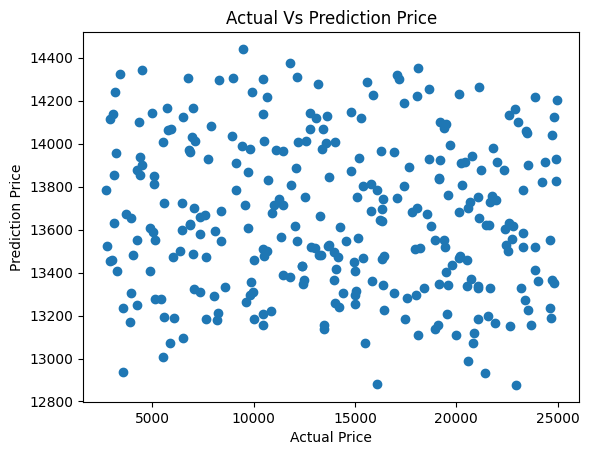

In [20]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Prediction Price")
plt.title("Actual Vs Prediction Price")
plt.show()

In [21]:
import pickle
pickle.dump(model, open("Flight_Price_Model.pkl","wb"))
print("Model saved successfully!")

Model saved successfully!


In [22]:
loaded_model = pickle.load(open("Flight_Price_Model.pkl","rb"))
print(loaded_model)

LinearRegression()
